In [1]:
# Import main packages

from tilepy.include.CampaignDefinition import ObservationParameters
from tilepy.include.ObservationScheduler import GetSchedule
from tilepy.include.PointingTools import getdate

/Users/as287950/projetCEA/tilepy_old/.venv/lib/python3.11/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/Users/as287950/projetCEA/tilepy_old/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

### Set of inputs needed to run the code

In [3]:
from astropy.io import fits

skymap = "../sciencecases/927563_lalinference/support/927563_lalinference.fits.gz"
hdul = fits.open(skymap)
print(hdul[1].header)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                16384 / length of dimension 1                          NAXIS2  =                 3072 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                    4 / number of table fields                         TTYPE1  = 'PROB    '                                                            TFORM1  = '1024E   '                                                            TUNIT1  = 'pix-1   '                                                            TTYPE2  = 'DISTMU  '                                                            TFORM2  = '1024E   '                    

In [4]:
# The url to the FITS file with the sky localization, e.g.for GW https://urlpath/Bayestar.fits.gz'
# Local file with 3D localization
skymap = "../sciencecases/927563_lalinference/support/927563_lalinference.fits.gz"
obsTime = getdate("2023-03-15 10:30:01")
pointingsFile = None


# BBH with 2D localization
# skymap = 'https://gracedb.ligo.org/api/superevents/S250328ae/files/Bilby.multiorder.fits,0'
# obsTime = getdate("2025-03-28 19:10:00")
# pointingsFile = '/Users/mseglar/GitHub/tilepy/examples/launcher/output/S250328ae/SuggestedPointings_2DProbOptimisation_firstRound.txt'
# pointingsFile = None

# Date and time of the event in format YYYY-MM-DD HH:MM:SS. You can use 2023-07-15 14:30:10 for the example .fits file


# Path to the input datasets (where galaxy cat should be for GW case)
datasetDir = "../../src/tilepy/dataset/"

# Path to the output folder
outDir = "./output"

# Config file for the tiling scheduling
cfgFile = "../config/FollowupParameters_LST.ini"

# Galaxy catalog name (if no catalog is given, the approach will be 2D). Path to th file is defined in datasetDir variable
galcatName = "Gladeplus.h5"

# Tiles already observed

In [5]:
# Parse the parameters
obspar = ObservationParameters()
obspar.add_parsed_args(skymap, obsTime, datasetDir, galcatName, outDir, pointingsFile)
obspar.from_configfile(cfgFile)

In [6]:
print(obspar)

============== Observation Parameters ======================
Observatory Name: LST
Event Name: None
obsTime: 2023-03-15 10:30:01
---------------------- Strategy ----------------------
Algorithm = 3D, Strategy = integrated,  Mangrove = False
Do Plot = True, Do Rank = True, Count Previous= True, Second Round= False, Use Grey Time= False
--------------------- Observatory ---------------------
Observatory Location: 28.761944 deg, -17.89 deg, 2200.0 m
Wobble Offset: 0.0 deg
FOV: 2.5, Duration: 20.0, Min Duration: 10.0, Min Slewing: 0.0
Max Runs: 4, Max Nights: 1
Visibility: -18, -0.5, 65, 0, 0.0
Min Moon Source Separation: 30
Max Moon Source Separation: 145
Geomagnetic Threshold for SAA: 0
Max Zenith: 70.0, Zenith Weighting: 0.75
FoV number of sides: 0, FoV rotation: 0,Priority for FoV proximity and Probability: 0.0, Zenith Weighting: 0.0
--------------------- Skymap considerations ----------------
Skymap: ../sciencecases/927563_lalinference/support/927563_lalinference.fits.gz
Cuts: MinProb

### Run the scheduling

Starting the 3D pointing calculation with the following parameters

Filename:  coinc_event:coinc_event_id:927563
Date: 2023-03-15 10:30:01
Previous pointings: None
Catalog: ../../src/tilepy/dataset/Gladeplus.h5
Dataset: ../../src/tilepy/dataset/
Output: output/coinc_event:coinc_event_id:927563
90% area = 398.17926483666673. 50% area = 121.42218532828433

Obspar:
============== Observation Parameters ======================
Observatory Name: LST
Event Name: coinc_event:coinc_event_id:927563
obsTime: 2023-03-15 10:30:01
---------------------- Strategy ----------------------
Algorithm = 3D, Strategy = integrated,  Mangrove = False
Do Plot = True, Do Rank = True, Count Previous= True, Second Round= False, Use Grey Time= False
--------------------- Observatory ---------------------
Observatory Location: 28.761944 deg, -17.89 deg, 2200.0 m
Wobble Offset: 0.0 deg
FOV: 2.5, Duration: 20.0, Min Duration: 10.0, Min Slewing: 0.0
Max Runs: 4, Max Nights: 1
Visibility: -18, -0.5, 65, 0, 0.0
Min Moon

Rasterizing map of type 'prob' at nside=512 with scheme='ring'
Rasterizing map of type 'prob_density' at nside=512 with scheme='ring'


Skymap is 3D
No pointings were given to be subtracted
----------   NEW FOLLOW-UP ATTEMPT   ----------
maxRuns: 4, MinimumProbCutForCatalogue: 0.01
Condition not met at 2023-03-15 20:38:21.908282+00:00: dp/dV_FOV = 0.005652329350812119 must be greater than 0.02
Condition not met at 2023-03-15 20:58:21.908282+00:00: dp/dV_FOV = 0.0 must be greater than 0.02

================================= Tiling found =============================================
     Time[UTC]      RA[deg]  DEC[deg]  PGW    Pgal  Round ObsName Duration FoV
------------------- -------- -------- ------ ------ ----- ------- -------- ---
2023-03-15 21:18:21  194.196   27.057 0.0292 0.1921     1     LST     20.0 2.5
2023-03-15 21:38:21  197.678  21.3666 0.0532 0.0324     1     LST     20.0 2.5
2023-03-15 21:58:21 198.7934   15.546 0.0909 0.0576     1     LST     20.0 2.5
2023-03-15 22:18:21  201.132  11.7704 0.0841 0.1145     1     LST     20.0 2.5

The total probability PGal: 0.3966
The total probability PGW: 0.2574

Res

Rasterizing map of type 'prob' at nside=512 with scheme='ring'


Name: output/coinc_event:coinc_event_id:927563/PGallinFoVintegrated
Loading pointings from output/coinc_event:coinc_event_id:927563/PGallinFoVintegrated/SuggestedPointings_GalProbOptimisation.txt
----------   PLOTTING THE SCHEDULING   ----------
Total covered probability with the scheduled tiles is PGW= 0.25740


Rasterizing map of type 'prob' at nside=512 with scheme='ring'


Plotting galaxies


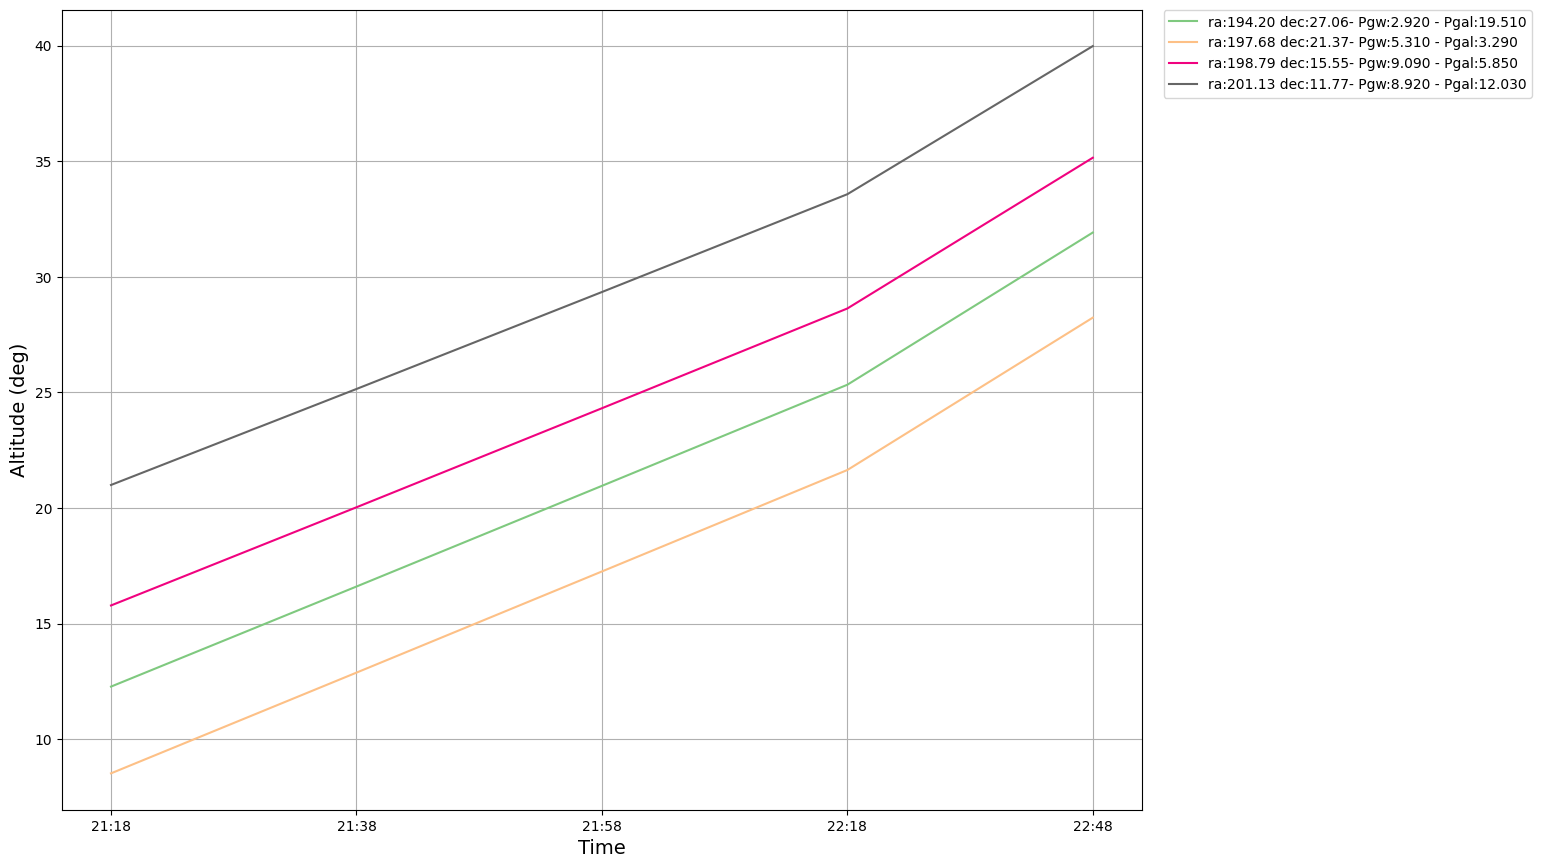

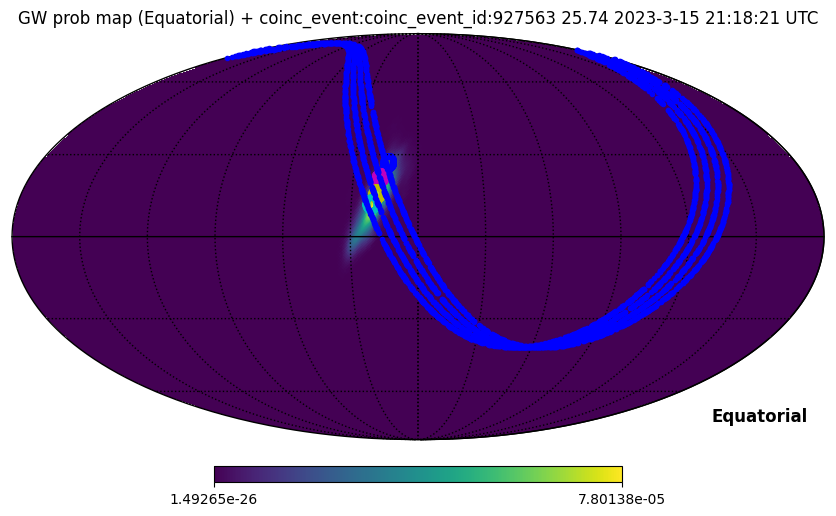

In [7]:
# Run the scheduler
GetSchedule(obspar)